# IMPORTS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from datetime import datetime
from diive.core.io.files import save_parquet, load_parquet

# LOAD DATA

In [2]:
night = pd.read_csv("84.1_NEE_NightTimeOnly_FilledWithXGBoost.csv")
day = pd.read_csv("84.1_NEE_DayTimeOnly_FilledWithXGBoost.csv")

In [3]:
day['TIMESTAMP_MIDDLE'] = pd.to_datetime(day['TIMESTAMP_MIDDLE'])
day.set_index('TIMESTAMP_MIDDLE', inplace=True)
day

,NEE_L3.3_CUT_50_QCF_gfXGBoost_ParcelA_all,NEE_L3.3_CUT_50_QCF_gfXGBoost_ParcelA_certain,NEE_L3.3_CUT_50_QCF_gfXGBoost_ParcelB_all,NEE_L3.3_CUT_50_QCF_gfXGBoost_ParcelB_certain
TIMESTAMP_MIDDLE,,,,
2023-11-08 07:45:00,1.106824,1.106824,2.051290,2.051290
2023-11-08 08:15:00,0.734900,0.734900,1.490991,1.490991
2023-11-08 08:45:00,-1.261421,-1.261421,-0.737125,-0.737125
2023-11-08 09:15:00,-5.650183,-5.650183,-5.187243,-5.187243
2023-11-08 09:45:00,-6.492434,-6.492434,-6.047488,-6.047488
...,...,...,...,...
2025-06-05 17:45:00,-6.936522,-6.936522,-6.716471,-6.716471
2025-06-05 18:15:00,-8.314410,-8.314410,-8.094361,-8.094361
2025-06-05 18:45:00,-3.949116,-3.949116,-3.729066,-3.729066


In [4]:
night['TIMESTAMP_MIDDLE'] = pd.to_datetime(night['TIMESTAMP_MIDDLE'])
night.set_index('TIMESTAMP_MIDDLE', inplace=True)
night

,NEE_L3.3_CUT_50_QCF_gfXGBoost
TIMESTAMP_MIDDLE,
2023-11-08 00:15:00,3.710068
2023-11-08 00:45:00,3.600918
2023-11-08 01:15:00,3.600918
2023-11-08 01:45:00,3.555548
2023-11-08 02:15:00,3.509664
...,...
2025-06-05 21:45:00,8.616221
2025-06-05 22:15:00,8.532531
2025-06-05 22:45:00,8.784100


# MERGE DATA

In [5]:
# 1) grab the single nighttime series
nt = night.iloc[:, 0]

# 2) expand it to all day columns (broadcast by index)
night_expanded = pd.DataFrame({col: nt for col in day.columns})

# 3) stack and sort by time
df = pd.concat([day, night_expanded], axis=0).sort_index()
df

,NEE_L3.3_CUT_50_QCF_gfXGBoost_ParcelA_all,NEE_L3.3_CUT_50_QCF_gfXGBoost_ParcelA_certain,NEE_L3.3_CUT_50_QCF_gfXGBoost_ParcelB_all,NEE_L3.3_CUT_50_QCF_gfXGBoost_ParcelB_certain
TIMESTAMP_MIDDLE,,,,
2023-11-08 00:15:00,3.710068,3.710068,3.710068,3.710068
2023-11-08 00:45:00,3.600918,3.600918,3.600918,3.600918
2023-11-08 01:15:00,3.600918,3.600918,3.600918,3.600918
2023-11-08 01:45:00,3.555548,3.555548,3.555548,3.555548
2023-11-08 02:15:00,3.509664,3.509664,3.509664,3.509664
...,...,...,...,...
2025-06-05 21:45:00,8.616221,8.616221,8.616221,8.616221
2025-06-05 22:15:00,8.532531,8.532531,8.532531,8.532531
2025-06-05 22:45:00,8.784100,8.784100,8.784100,8.784100


# PLOT

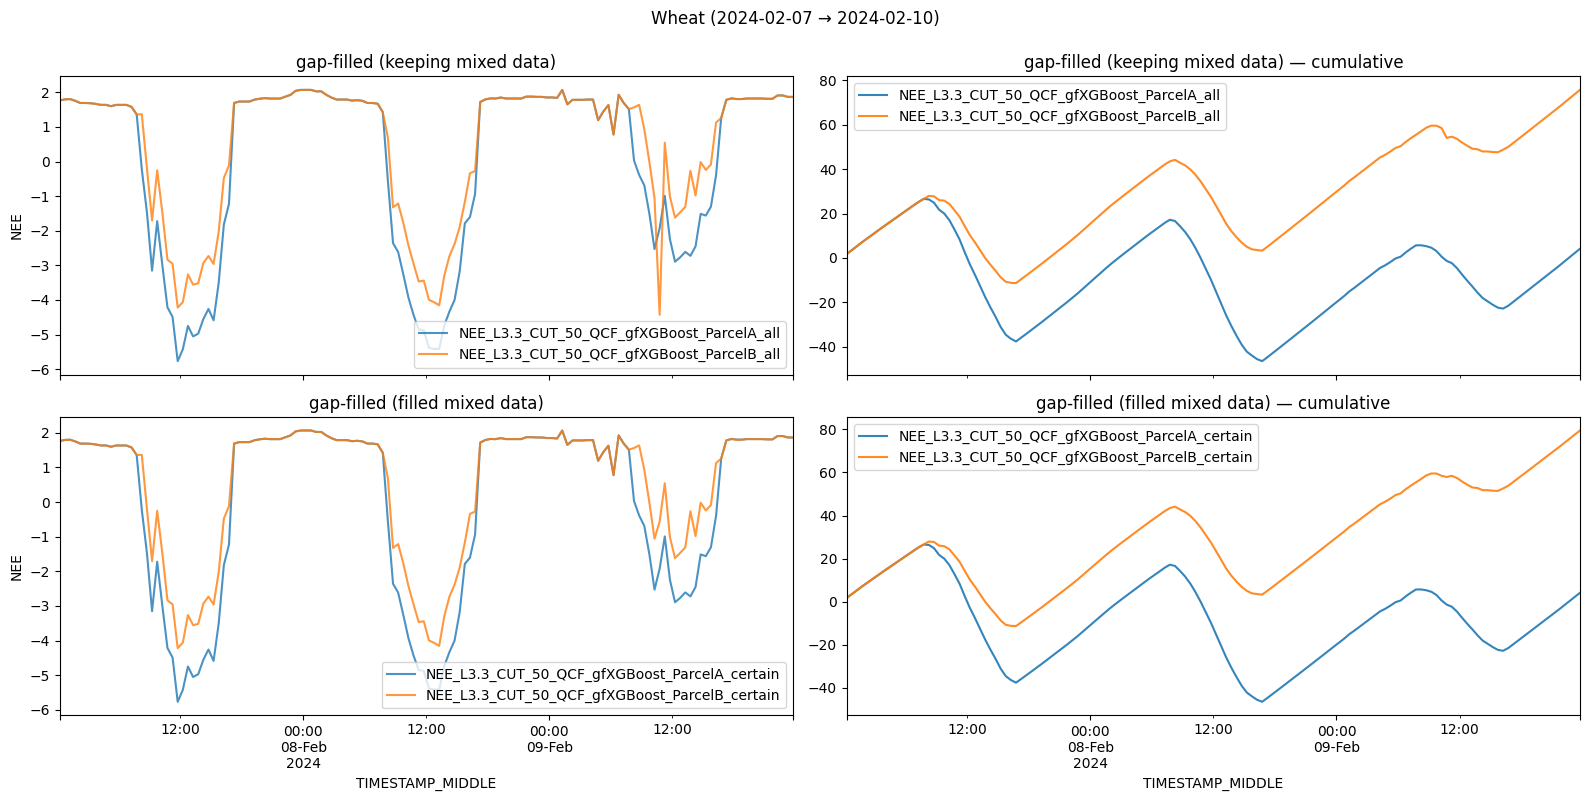

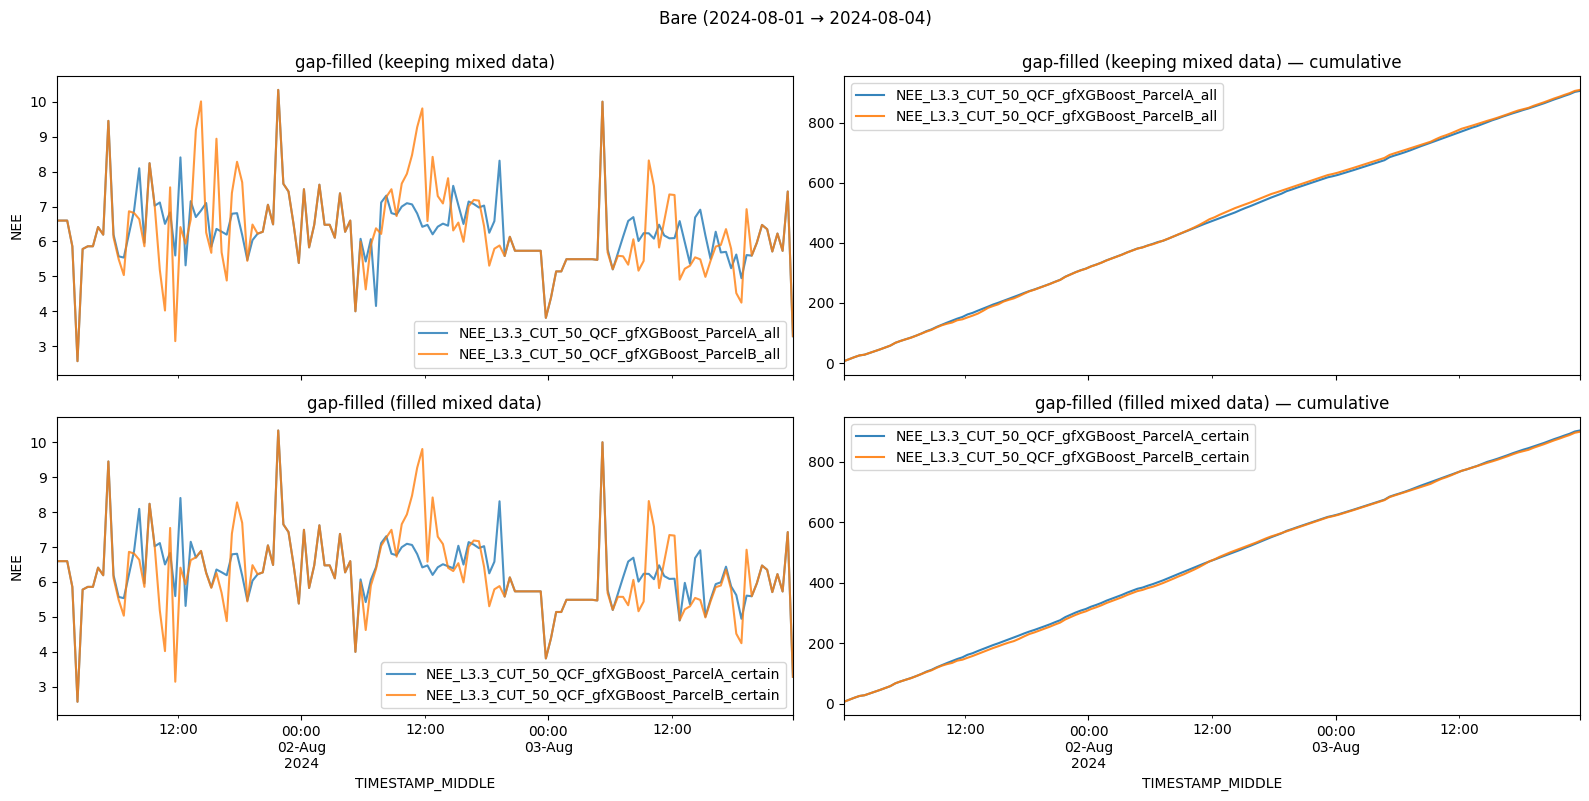

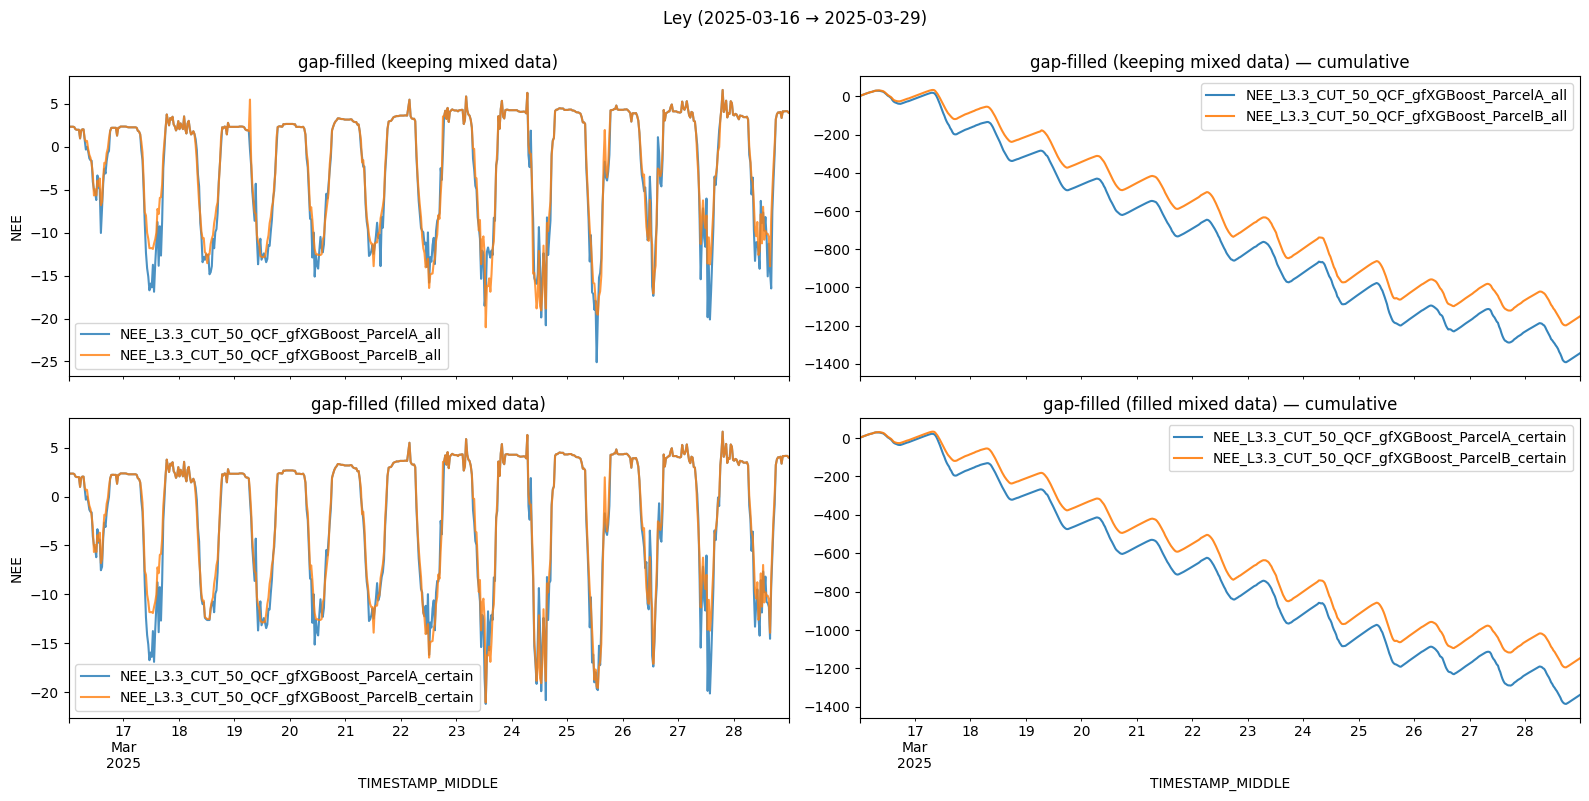

In [6]:
# Plots

# Define periods
periods = [
    ("2023-11-07", "2024-07-25", "Wheat"),
    ("2024-07-26", "2024-09-15", "Bare"),
    ("2024-09-16", "2025-06-05", "Ley"),
]

periods = [
    ("2024-02-07", "2024-02-10", "Wheat"),
    ("2024-08-01", "2024-08-04", "Bare"),
    ("2025-03-16", "2025-03-29", "Ley"),
]

for start, end, label in periods:
    period_df = df.loc[pd.to_datetime(start):pd.to_datetime(end)]
    pairs = [
        ([c for c in df.columns if c.endswith('all')], "gap-filled (keeping mixed data)"),
        ([c for c in df.columns if c.endswith('certain')], "gap-filled (filled mixed data)"),
    ]

    # Keep only existing columns
    pairs = [(cols, t) for cols, t in pairs if all(c in period_df.columns for c in cols)]
    if not pairs: 
        continue

    nrows, ncols = len(pairs), 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows), sharex='col')
    if nrows == 1:  # make indexing uniform
        axes = axes.reshape(1, ncols)

    for r, (cols, t) in enumerate(pairs):
        # raw
        period_df[cols].plot(ax=axes[r, 0], alpha=0.8)
        axes[r, 0].set_title(f"{t}")
        axes[r, 0].set_ylabel('NEE')

        # cumulative
        cumulative = period_df[cols].fillna(0).cumsum()
        cumulative.plot(ax=axes[r, 1], alpha=0.9)
        axes[r, 1].set_title(f"{t} — cumulative")

    fig.suptitle(f"{label} ({start} → {end})", y=0.995, fontsize=12)
    plt.tight_layout()
    plt.show()

# EXPORT

Check timestamp

In [7]:
# 1) sorted?
is_sorted = df.index.is_monotonic_increasing
# (optional) sort to proceed robustly
idx = df.index if is_sorted else df.sort_index().index

# 2) duplicates?
has_dups = idx.duplicated().any()
dup_count = idx.duplicated().sum()

# 3) infer sampling step (falls back to modal step if needed)
freq = pd.infer_freq(idx)
if freq is None:
    diffs = pd.Series(idx).diff().dropna()
    step = diffs.mode().iloc[0]  # Timedelta
else:
    step = pd.tseries.frequencies.to_offset(freq)

# 4) missing timestamps vs. expected full range
expected = pd.date_range(idx[0], idx[-1], freq=step)
missing_ts = expected.difference(idx)           # Index of missing timestamps
has_missing = len(missing_ts) > 0

# 5) NaNs in data
nan_cols = df.columns[df.isna().any()]
nan_total = int(df.isna().sum().sum())

print(f"Sorted index: {is_sorted}")
print(f"Duplicates: {has_dups} (count={dup_count})")
print(f"Inferred step: {step}")
print(f"Missing timestamps: {has_missing} (count={len(missing_ts)})")
print(f"Columns with NaNs: {list(nan_cols)} (total NaNs={nan_total})")

# If you want to see a few gaps:
print(missing_ts[:10])


Sorted index: True
Duplicates: False (count=0)
Inferred step: <30 * Minutes>
Missing timestamps: False (count=0)
Columns with NaNs: [] (total NaNs=0)
DatetimeIndex([], dtype='datetime64[ns]', freq='30min')


Export

In [8]:
OUTNAME = "85.1_NEE_GapfillingResults"
filepath = save_parquet(filename=OUTNAME, data=df)
df.to_csv(f"{OUTNAME}.csv")

Saved file 85.1_NEE_GapfillingResults.parquet (0.376 seconds).


Partitioning subset for ReddyProc

In [9]:
from diive.core.times.times import insert_timestamp
meteo = load_parquet(filepath=r"../../10_METEO/13.1_CH-TAN_meteo_gapfilled.parquet")
fluxes = load_parquet(filepath=r"../../70_SPLIT_TREATMENTS/71.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC_PARCELS.parquet")
fluxes = fluxes['USTAR']
meteo = meteo[['ta', 'sw_in', 'vpd', 'ppfd', 'rh']]
export_REddyProc = pd.concat([df, meteo, fluxes], axis=1)
export_REddyProc = insert_timestamp(data=export_REddyProc, convention="end", set_as_index=True)
export_REddyProc

Loaded .parquet file ../../10_METEO/13.1_CH-TAN_meteo_gapfilled.parquet (0.679 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
Loaded .parquet file ../../70_SPLIT_TREATMENTS/71.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC_PARCELS.parquet (0.563 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,NEE_L3.3_CUT_50_QCF_gfXGBoost_ParcelA_all,NEE_L3.3_CUT_50_QCF_gfXGBoost_ParcelA_certain,NEE_L3.3_CUT_50_QCF_gfXGBoost_ParcelB_all,NEE_L3.3_CUT_50_QCF_gfXGBoost_ParcelB_certain,ta,sw_in,vpd,ppfd,rh,USTAR
TIMESTAMP_END,,,,,,,,,,
2023-11-01 00:00:00,NaN,NaN,NaN,NaN,8.000000,0.0,0.216913,0.0,79.800000,NaN
2023-11-01 00:30:00,NaN,NaN,NaN,NaN,8.633333,0.0,0.272054,0.0,75.733333,NaN
2023-11-01 01:00:00,NaN,NaN,NaN,NaN,8.266667,0.0,0.257705,0.0,76.433333,NaN
2023-11-01 01:30:00,NaN,NaN,NaN,NaN,6.966667,0.0,0.171078,0.0,82.900000,NaN
2023-11-01 02:00:00,NaN,NaN,NaN,NaN,5.666667,0.0,0.104550,0.0,88.566667,NaN
...,...,...,...,...,...,...,...,...,...,...
2025-06-05 22:00:00,8.616221,8.616221,8.616221,8.616221,15.833333,0.0,0.285270,0.0,84.166667,NaN
2025-06-05 22:30:00,8.532531,8.532531,8.532531,8.532531,15.733333,0.0,0.289417,0.0,83.833333,NaN
2025-06-05 23:00:00,8.784100,8.784100,8.784100,8.784100,16.200000,0.0,0.404542,0.0,78.066667,NaN


In [10]:
filename = "85.2_PartitioningSubsetForREddyProc"
export_REddyProc.to_csv(f"{filename}.csv", index=True)

# End of notebook

In [11]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-10-06 11:34:43
